In [1]:
import json
import copy
from torch.utils.data import Dataset
import datas
class RaftLogDataSet(Dataset):
    def __init__(self, datafilesName):
        self.datafilesName = datafilesName
        self.serversOrignDatas = []
        for i,fileName in enumerate( self.datafilesName):
           with open(fileName, 'r') as f:
                lines = f.readlines()
                tmp = []
                for line in lines:
                    if len(line) < 2:continue
                    js_data = json.loads(line)
                    if('role' in js_data):
                        if(js_data['role'] == 'action' and js_data['action'] == 'change_state'):
                            js_data['me'] = i
                    tmp.append(js_data)
                self.serversOrignDatas.append(tmp)
                f.close()
        print("load datafiles done...")      
        self.all_servers_datasets = []
        
       
        for serverOrignData in self.serversOrignDatas:
            flattend_jsons = []
            for js_data in serverOrignData:
                if ('role' not in js_data) or (line is None) or ('timestamp' not in js_data):
                    continue
                keys,values = datas.flattenJson(js_data)
                if(len(keys) != len(values)):continue
                tmp_js = dict(zip(keys,values))
                if(tmp_js['role'] == 'state'):
                    tmp_js.pop('raft_state.ip_index')
                    tmp_js.pop('raft_state.nextIndex')
                    lo_rx_str = 'system_state.network.process.lo:.RX Bytes'
                    lo_tx_str = 'system_state.network.process.lo:.TX Bytes'
                    tmp_js.pop(lo_rx_str)
                    tmp_js.pop(lo_tx_str)
                flattend_jsons.append(tmp_js)
            self.all_servers_datasets.append(flattend_jsons)
        print("flattend_jsons ...")
        combined_actionTuples = []
        '''
        combined_actionTuples :[ (timestamp,[(serverId,actionJson,index) ... ]) ... ]
        '''
        def timestampIsExistInTuples(combined_actionTuples,timeStamp) -> int:
            for i in range(len(combined_actionTuples)):
                if combined_actionTuples[i][0] == timeStamp:
                    return i
            return -1
        
        def getPrevStateJsonInServerByIndex(serverId,actionIndex):
            serverDatas = self.all_servers_datasets[serverId]
            for i in range(actionIndex,-1,-1):
                if serverDatas[i]['role'] == 'state':
                    return serverDatas[i]
            return None

        def getNextStateJsonInServerByIndex(serverId,actionIndex):
            serverDatas = self.all_servers_datasets[serverId]
            for i in range(actionIndex,len(serverDatas)):
                if serverDatas[i]['role'] == 'state':
                    return serverDatas[i]
            return None
        
        for serverId in range(len(self.all_servers_datasets)):
            serverDatas = self.all_servers_datasets[serverId]
            for i  in range(len(serverDatas)):
                json_data = serverDatas[i]
                if(json_data['role'] != 'action'):continue
                timestamp = json_data['timestamp']
                idx = timestampIsExistInTuples(combined_actionTuples,timestamp)
                tuple_ = (serverId,json_data,i)
                if idx == -1:
                    combined_actionTuples.append((timestamp,[tuple_]))
                else:   
                    combined_actionTuples[idx][1].append(tuple_)
                    
        self.train_data_each_batch_by_logicOrder = []
        for tp_ in combined_actionTuples:
            # tp_ : (timestamp,[(serverId,actionJson,index) ... ])
            actionTupleList = tp_[-1]
            grouped_by_serverId = {}
            for actionTuple in actionTupleList:
                # actionTuple : (serverId,actionJson,index)
                serverId = actionTuple[0]
                if serverId not in grouped_by_serverId:
                    grouped_by_serverId[serverId] = []
                grouped_by_serverId[serverId].append(actionTuple)
                
            batch_tuple = {}
            for serverId in grouped_by_serverId:
                batch_tuple[serverId] = {
                    'prevStateJson' : None,
                    'actions' : [],
                    'nextStateJson':None
                }
                actionTuples = grouped_by_serverId[serverId]
                prevStateJson = None
                nextStateJson = None
                # actionTuple: (serverId,actionJson,index)
                for actionTuple in actionTuples:
                    actionJson = actionTuple[1]
                    index = actionTuple[2]
                    if prevStateJson is None:
                        prevStateJson = getPrevStateJsonInServerByIndex(serverId,index)
                    if nextStateJson is None:
                        nextStateJson = getNextStateJsonInServerByIndex(serverId,index)
                    batch_tuple[serverId]['actions'].append(actionJson)
                batch_tuple[serverId]['prevStateJson'] = prevStateJson
                batch_tuple[serverId]['nextStateJson'] = nextStateJson
            self.train_data_each_batch_by_logicOrder.append(batch_tuple)
          

    def __getitem__(self, index):
        
        if(index >= len(self.train_data_each_batch_by_logicOrder) or index < 0):
            raise IndexError("Index out of range")
        batch_tuple = self.train_data_each_batch_by_logicOrder[index]
        once_prevStateJson = []
        once_actions = []
        once_nextStateJson = []
        for serverId in batch_tuple:
            item = batch_tuple[serverId]
            prevStateJson = item['prevStateJson']
            nextStateJson = item['nextStateJson']
            actions = item['actions']
            once_prevStateJson.append(prevStateJson)
            once_nextStateJson.append(nextStateJson)
            once_actions.append(actions)  
        return (once_prevStateJson,once_actions,once_nextStateJson  )
    
    def __len__(self):
        return len(self.train_data_each_batch_by_logicOrder)


In [2]:
datafilesName = ['/home/cdy/code/projects/cRaft/.data/system_data/server-128-0/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-130-1/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-131-2/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-133-3/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/.data/system_data/server-134-4/system_runtime.data0',
                ]
datafilesName = ['/home/cdy/code/projects/cRaft/src/train/data_util/tmpdata/system_data/server-128-0/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/src/train/data_util/tmpdata/system_data/server-130-1/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/src/train/data_util/tmpdata/system_data/server-131-2/system_runtime.data0',
                     '/home/cdy/code/projects/cRaft/src/train/data_util/tmpdata/system_data/server-133-3/system_runtime.data0',
                     '//home/cdy/code/projects/cRaft/src/train/data_util/tmpdata/system_data/server-134-4/system_runtime.data0',
                ]
dataset = RaftLogDataSet(datafilesName)


load datafiles done...
flattend_jsons ...


In [3]:
import math
def handleOriginFlattendJson(js):
    lo_rx_str = 'system_state.network.process.lo:.RX Bytes'
    lo_tx_str = 'system_state.network.process.lo:.TX Bytes'
    if(lo_rx_str in js):js.pop(lo_rx_str)
    if(lo_tx_str in js):js.pop(lo_tx_str)
    if('timestamp' in js):js.pop('timestamp')
    if('role' in js):js.pop('role')
    if('raft_state.ip_index' in js):js.pop('raft_state.ip_index')
    if('raft_state.nextIndex' in js):js.pop('raft_state.nextIndex')
    if('ip_index' in js):js.pop('ip_index')
    if('nextIndex' in js):js.pop('nextIndex')
    # if('raft_state.commitIndex' in js):js.pop('raft_state.commitIndex')
    # if('raft_state.lastLogIndex' in js):js.pop('raft_state.lastLogIndex')
    if('raft_state.logsize' in js):js.pop('raft_state.logsize')
    if('raft_state.snapShotIndex' in js):js.pop('raft_state.snapShotIndex')
    if('raft_state.snapShotTerm' in js):js.pop('raft_state.snapShotTerm')
    # if('raft_state.term' in js):js.pop('raft_state.term')
    for key in js:
        if js[key] is None:
            js[key] = 0
        if(key.startswith('system_state')):
            js[key] = math.log10(1 + js[key])
    return js
import torch
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batchs = []
one_batch_x = []
one_batch_y = []
batch_size =40

keep_servers_nearest_state = {0:None,1:None,2:None,3:None,4:None}
for time_step in range(len(dataset)):
    if(len(one_batch_x) == batch_size):
        batchs.append((one_batch_x,one_batch_y))
        one_batch_x = []
        one_batch_y = []
    once_prevStateJson,once_actions,once_nextStateJson = dataset[time_step]
    once_nextStateJson = copy.deepcopy(once_nextStateJson)
    once_prevStateJson = copy.deepcopy(once_prevStateJson)
    once_actions = copy.deepcopy(once_actions)
    for prevJson in once_prevStateJson:
        if(prevJson is None):continue
        prevJson = handleOriginFlattendJson(prevJson)
        serverid = prevJson['raft_state.id']
        ens_rx_str = 'system_state.network.process.ens33:.RX Bytes'
        ens_tx_str = 'system_state.network.process.ens33:.TX Bytes'
      
        dis_ens_rx_bytes = abs(prevJson[ens_rx_str] - prevJson[ens_rx_str])
        dis_ens_tx_bytes = abs(prevJson[ens_tx_str] - prevJson[ens_tx_str])
     
        prevJson[ens_rx_str] = dis_ens_rx_bytes
        prevJson[ens_tx_str] = dis_ens_tx_bytes
        keep_servers_nearest_state[serverid] = list(prevJson.values())
        
    is_state_changed = False
    label_list = [[0] * len(datas.Action) for _ in range(5)]
    for servers_actionlist in once_actions:
        for action_json in servers_actionlist:
            # is_ok ,success, is voted
            if(action_json is None):continue
            action_json = handleOriginFlattendJson(action_json)
            cur_action = action_json['action']
            me = -1
            if(action_json['action'] == datas.Action.CHANGE_STATE.value):
                me = action_json['me']
            else:
                if('me' in action_json):
                    me = action_json['me']
                elif ('id' in action_json):
                    me = action_json['id']
            if(cur_action == datas.Action.CHANGE_STATE.value):
                to_state = datas.state_to_int[action_json['to']].value
                if(to_state == datas.State.LEADER.value):
                    label_list[me][datas.Action.TO_L.value] = 1
                    label_list[me][datas.Action.CHANGE_STATE.value] = 1
                    for i in range(5):
                        if i == me:continue
                        label_list[i][datas.Action.TO_F.value] = 1
                        label_list[me][datas.Action.CHANGE_STATE.value] = 1
                    is_state_changed = True
                    break
            else:
                is_ok = False
                peer = -1
                if('is_ok' in action_json):
                    is_ok = action_json['is_ok']
                elif ('success' in action_json):
                    is_ok = action_json['success']
                elif ('is_voted' in action_json):
                    is_ok = action_json['is_voted']
                if('peer' not in action_json):
                    peer = action_json['to']
                else:
                    peer = action_json['peer']
                action_peer = None
                if(peer == 0):
                    action_peer = datas.Action.CALL_0.value
                elif(peer == 1):
                    action_peer = datas.Action.CALL_1.value
                elif(peer == 2):    
                    action_peer = datas.Action.CALL_2.value
                elif(peer == 3):
                    action_peer = datas.Action.CALL_3.value
                elif(peer == 4):
                    action_peer = datas.Action.CALL_4.value
                if(action_peer is None):continue
                if(is_ok):
                    label_list[me][action_json['action']] = 1
                    label_list[me][action_peer]  = 1
        if(is_state_changed):break
    x = list(keep_servers_nearest_state.values())
    y = label_list

    is_contain_none = False
    for item in x:
        if(item is None):
            is_contain_none = True
            break
    if(is_contain_none):continue
           
    one_batch_x.append(x)
    one_batch_y.append(y)
if(len(one_batch_x) > 0):
    batchs.append((one_batch_x,one_batch_y))
print(len(batchs))

217


In [4]:
import action_model
num_eopchs = 50
num_servers = len(datafilesName)
action_num = len(datas.Action)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_width =len(batchs[0][0][0][0]) # StateJson 的特征维度
embed_dim = 512
num_heads = 8
lr = 0.0001
train_ratio = 0.85
train_len = int(len(batchs) * train_ratio)
train_batchs = batchs[:train_len]
test_batchs = batchs[train_len:]
model =action_model.CenterActionNetWork(num_servers,action_num,input_width,embed_dim,num_heads).to(device)
#初始化模型参数
def init_weights(m):
    if type(m) == torch.nn.Linear:
        torch.nn.init.xavier_uniform(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

loss_fn =  torch.nn.BCEWithLogitsLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.train()
####################
avg_loss = []
losses = []
test_loss = []
random.shuffle(batchs)
train_len = int(len(batchs) * train_ratio)
train_batchs = batchs[:train_len]
test_batchs = batchs[train_len:]
min_test_loss = 1000000
for epoch in range(num_eopchs):
    random.shuffle(train_batchs)
    model.train()

    for (batch_x,batch_y) in train_batchs:
        input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
        y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)

        output = model(input_x)
        output = output.view(-1,action_num)
        y_label = y_label.view(-1,action_num)
        loss = loss_fn(output, y_label)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        print(epoch,loss.item())
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
      
    # # # eval model
    model.eval()
    temp_loss = []
    for batch_x,batch_y in test_batchs:
        input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
        y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)
        output = model(input_x)
        output = output.view(-1,action_num)
        y_label = y_label.view(-1,action_num)
        loss = loss_fn(output, y_label)
        test_loss.append(loss.item())
        temp_loss.append(loss.item())
    if(len(temp_loss) == 0):continue
    tmp_avg_loss = sum(temp_loss) / len(temp_loss)
    temp_loss = []
    if(tmp_avg_loss < min_test_loss):
        min_test_loss = tmp_avg_loss
        torch.save(model, f'{epoch}-{min_test_loss}-model.pth')
        
print("train done")

/tmp/ipykernel_201544/2524863792.py:18: UserWarning: nn.init.xavier_uniform is now deprecated in favor of nn.init.xavier_uniform_.
  torch.nn.init.xavier_uniform(m.weight)


0 40.15217590332031
0 45.48533248901367
0 3.346320390701294
0 10.707172393798828
0 21.97819709777832
0 10.626497268676758
0 4.330795764923096
0 1.230721116065979
0 83.21833038330078
0 26.692026138305664
0 29.27067756652832
0 11.721766471862793
0 3.9022626876831055
0 1.5177375078201294
0 1.2936638593673706
0 6.723049640655518
0 27.667165756225586
0 13.01313304901123
0 17.123668670654297
0 1.4353833198547363
0 4.048863887786865
0 1.7556849718093872
0 4.7638349533081055
0 3.7860162258148193
0 2.9611258506774902
0 5.18922758102417
0 2.8566787242889404
0 1.834913969039917
0 2.1327803134918213
0 7.470466613769531
0 1.502362608909607
0 7.015174388885498
0 2.146005153656006
0 1.3843575716018677
0 1.1374818086624146
0 1.1433210372924805
0 1.6143007278442383
0 0.5436743497848511
0 4.99818754196167
0 0.6601672768592834
0 0.29081445932388306
0 0.3193187415599823
0 0.2651331424713135
0 0.27601832151412964
0 0.17873059213161469
0 6.049200534820557
0 9.321199417114258
0 0.08902451395988464
0 5.017347

In [6]:
len(batchs)

0

In [9]:
model.eval()   
tmp = [] 
for (x,y) in batchs:
    input_x = torch.tensor(x,dtype=torch.float).to(device)
    out = model(input_x)
    probs = torch.sigmoid(out)
    predictions = (probs > 0.5).int()  
    tmp.append(predictions)


217


In [15]:
for b in tmp:
    for i in range(len(b)):
        for j in range(len(b[i])):
            if(b[i][j][0] == 1):


In [5]:
# calculate the last test loss
last_test_loss = []
model.eval()
tmp = []
for batch_x,batch_y in test_batchs:
    input_x = torch.tensor(batch_x,dtype=torch.float).to(device)
    y_label =  torch.tensor(batch_y,dtype=torch.float).to(device)
    output = model(input_x)
    probs = torch.sigmoid(output)  # shape: (batch_size, 5, 16)

# 使用阈值（比如 0.5）来决定每个主机选择了哪些动作
    predictions = (probs > 0.5).int()  # 将概率大于 0.5 的动作标记为 1，其他为 0
 
    tmp.append(predictions)
    loss = loss_fn(output, y_label)
    last_test_loss.append(loss.item())
print("last test loss:",sum(last_test_loss)/len(last_test_loss))

last test loss: 0.048476707654368976


In [7]:
for b in tmp:
    for i in range(len(b)):
        print(b[i])
    print("===============")

tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0]], device='cuda:0',
       dtype=torch.int32)
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0]], device='cuda:0',
       dtype=torch.int32)
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0]], device='cuda:0',
       dtype=torch.int32)
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 

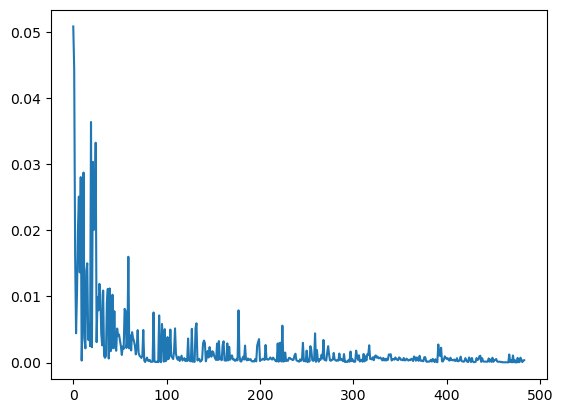

In [7]:
from matplotlib import pyplot as plt
import numpy as np
def readLossFileToList(fileName):
    with open(fileName, 'r') as f:
        lines = f.readlines()
        losses = []
        for line in lines:
            if len(line) < 2:continue
            losses.append(float(line))
        f.close()
    return losses

def average_k_elements(lst, k):
    if k <= 0:
        raise ValueError("K must be a positive integer greater than zero.")
    averages = []
    for i in range(0, len(lst), k):
        group = lst[i:i+k]  
        group_average = sum(group) / len(group)  
        averages.append(group_average)  
    return averages

#归一化函数
def normalize(lst):
    s = sum(lst)
    return list(map(lambda x: x/s, lst))

k = 10
# losses_list = readLossFileToList('../out/loss.txt')
# test_loss_list = readLossFileToList('../out/test_loss.txt')
# last_test_loss_list = readLossFileToList('../out/last_test_loss.txt')
losses_list = losses
test_loss_list = test_loss
last_test_loss_list = last_test_loss
result = average_k_elements(losses_list[:],1)

plt.plot(normalize(result),label='train loss')
# result = average_k_elements(test_loss_list[:],k)
# plt.plot(result,label='test loss')
# result = average_k_elements(last_test_loss_list[:],k)
# plt.plot(result,label='last test loss')



